<h1> NBA Data Mining Project </h1>
By Samuel Scott and Yubi Joy Quinzon

<b>Project Objective: </b>Develop a classification model that predicts whether an NBA player will score over or under a
predefined point threshold in a given game. The model leverages historical player performance
data, opponent defensive metrics, and contextual game features to estimate the likelihood of
exceeding the threshold.

In [1]:
# Preprocessing data
import numpy as np
import pandas as pd

# Creating vizualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting and training our model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluating our model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pulling in our kaggle dataset (which is updated daily) and replacing existing file with new
import shutil
import os
from datetime import datetime
import kaggle

# Supress warnings
import warnings
warnings.filterwarnings('ignore')

<h2> Kaggle API - Automated data retrieval</h2>
This code automates the process of retrieving the latest dataset, with the core functionality centered around the Kaggle API. At a high level, it checks whether a recent version of the dataset already exists locally and skips the download if it is up-to-date.

In [2]:
# Creating a variable of zip file name that is downloaded from kaggle
zip_file = 'historical-nba-data-and-player-box-scores.zip'

# Checks to see if zip file already exists with todays date
# If file does exists, we skip download
# If not we delete old zip file and redownload the lastest file
if os.path.exists(zip_file) and datetime.now().date() == datetime.fromtimestamp(os.path.getmtime(zip_file)).date():
    print("File has already been download, Skipping!.")

else:
    # Remove old files if new date
    if os.path.exists(zip_file):
        os.remove(zip_file)

    if os.path.exists("data"):
        shutil.rmtree("data")

    # Using the kaggle api to re-download and unzip
    !kaggle datasets download -d eoinamoore/historical-nba-data-and-player-box-scores --force
    !unzip -o historical-nba-data-and-player-box-scores.zip -d data/

player_stats = pd.read_csv('data/PlayerStatistics.csv', low_memory=False)
player_stats 

File has already been download, Skipping!.


,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Royce,O'Neale,1626220.0,22501185,2026-04-10 22:30:00,Phoenix,Suns,Los Angeles,Lakers,Regular Season,...,0.286,2.0,1.0,0.500,6.0,1.0,7.0,3.0,1.0,0.0
1,Luke,Kennard,1628379.0,22501185,2026-04-10 22:30:00,Los Angeles,Lakers,Phoenix,Suns,Regular Season,...,0.500,5.0,5.0,1.000,1.0,0.0,1.0,0.0,1.0,14.0
2,Dillon,Brooks,1628415.0,22501185,2026-04-10 22:30:00,Phoenix,Suns,Los Angeles,Lakers,Regular Season,...,0.000,4.0,2.0,0.500,0.0,2.0,2.0,4.0,3.0,-17.0
3,Maxi,Kleber,1628467.0,22501185,2026-04-10 22:30:00,Los Angeles,Lakers,Phoenix,Suns,Regular Season,...,0.000,2.0,0.0,0.000,0.0,0.0,0.0,2.0,0.0,3.0
4,Grayson,Allen,1628960.0,22501185,2026-04-10 22:30:00,Phoenix,Suns,Los Angeles,Lakers,Regular Season,...,0.200,3.0,3.0,1.000,3.0,1.0,4.0,0.0,2.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1667169,Tanner,Krebs,196295485.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.000,0.0,0.0,0.000,1.0,1.0,2.0,2.0,0.0,-10.0
1667170,Fabijan,Krslovic,196295487.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.000,4.0,3.0,0.750,1.0,2.0,3.0,1.0,1.0,-21.0
1667171,Nicholas,Tata,196295488.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.000,0.0,0.0,0.000,1.0,1.0,2.0,3.0,1.0,-8.0
1667172,Austin,Wiley,196295491.0,12500026,NaN,Hapoel,NaN,NaN,NaN,Pre Season,...,0.000,7.0,6.0,0.857,7.0,4.0,11.0,3.0,1.0,0.0


<h2>Data Exploration & Cleaning</h2>

In [3]:
# Column information of data - some type inconsistentcies like date (in the form of a string)
player_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1667174 entries, 0 to 1667173
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1666940 non-null  str    
 1   lastName                 1666936 non-null  str    
 2   personId                 1667129 non-null  float64
 3   gameId                   1667174 non-null  int64  
 4   gameDateTimeEst          1663446 non-null  str    
 5   playerteamCity           1667006 non-null  str    
 6   playerteamName           1663446 non-null  str    
 7   opponentteamCity         1663278 non-null  str    
 8   opponentteamName         1663446 non-null  str    
 9   gameType                 1667124 non-null  str    
 10  gameLabel                96782 non-null    str    
 11  gameSubLabel             6497 non-null     str    
 12  seriesGameNumber         135048 non-null   float64
 13  win                      1663436 non-null  float64
 1

In [4]:
# Size of our data
player_stats.shape

(1667174, 35)

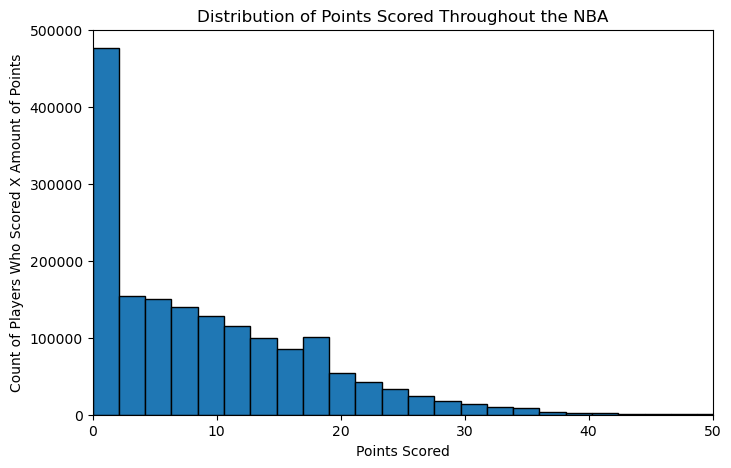

In [5]:
#Shows distribution of points across the NBA history.
points = player_stats['points']

plt.figure(figsize=(8,5))
plt.hist(points, bins=50, edgecolor='black')
plt.title("Distribution of Points Scored Throughout the NBA")
plt.xlabel("Points Scored")
plt.ylabel("Count of Players Who Scored X Amount of Points")
plt.xlim(0, 50) #Set a limit to 50 points since scoring above 50 is a rare feat in the NBA. 
plt.show()

In [6]:
# Count nulls per attribute
null_counts = player_stats.isnull().sum()
null_counts.sort_values(ascending = False)

gameSubLabel               1660677
gameLabel                  1570392
seriesGameNumber           1532126
numMinutes                  168755
opponentteamCity              3896
win                           3738
home                          3728
gameDateTimeEst               3728
playerteamName                3728
opponentteamName              3728
plusMinusPoints               2666
threePointersAttempted        1718
reboundsOffensive             1718
reboundsTotal                 1718
foulsPersonal                 1718
turnovers                     1718
reboundsDefensive             1718
freeThrowsPercentage          1718
freeThrowsMade                1718
freeThrowsAttempted           1718
threePointersPercentage       1718
threePointersMade             1718
assists                       1718
fieldGoalsPercentage          1718
fieldGoalsMade                1718
fieldGoalsAttempted           1718
steals                        1718
blocks                        1718
points              

In [7]:
# Types of games
player_stats['gameType'].unique().tolist()

['Regular Season',
 'All-Star Game',
 nan,
 'Emirates NBA Cup',
 'in-season-knockout',
 'Preseason',
 'Playoffs',
 'Play-in Tournament',
 'NBA Cup',
 'NBA Emirates Cup',
 'Pre Season']

In [8]:
# Shows that games will null values in date time are tied to only preseason games which we will drop
player_stats[player_stats['gameDateTimeEst'].isnull()]['gameType'].unique().tolist()

['Pre Season']

In [9]:
# Dropping records with null values of identifying metrics
player_stats = player_stats.dropna(subset=["personId", "gameId", "numMinutes", "gameType"])

In [10]:
# Dropping uncompetative game types that are unrepresentative of the rest of the data
player_stats = player_stats[~player_stats["gameType"].isin(["Preseason", "All-Star Game", "Pre Season"])]

In [11]:
# Changing date type from string to datetime
player_stats["gameDateTimeEst"] = pd.to_datetime(player_stats["gameDateTimeEst"])

# Changing data type from string to number
player_stats['numMinutes'] = pd.to_numeric(player_stats['numMinutes'], errors='coerce')

In [12]:
# Count nulls per attribute - notice we reduced most of our nulls
null_counts = player_stats.isnull().sum()
null_counts[null_counts > 0]

gameLabel           1371929
gameSubLabel        1442194
seriesGameNumber    1332286
dtype: int64

<b>Relief to see </b>as we can see all of our null values for key performance metrics have been removed

In [13]:
# Here we are creating our target variable, determines if the record is over or under the point threshold
# Using numpy for efficiency
player_stats["threshold_10"] = np.where(player_stats["points"] > 10, 1, 0)
player_stats["threshold_15"] = np.where(player_stats["points"] > 15, 1, 0)
player_stats["threshold_20"] = np.where(player_stats["points"] > 20, 1, 0)
player_stats["threshold_25"] = np.where(player_stats["points"] > 25, 1, 0)

In [14]:
rolling_average_stats = player_stats

# Sorting our data by player and date to calculate rolling averages
rolling_average_stats = rolling_average_stats.sort_values(["personId", "gameDateTimeEst"])
groupby_personid = rolling_average_stats.groupby("personId")

rolling_average_stats["rolling_avg_points"] = groupby_personid["points"].transform(
    lambda x: # X is the current metric (points in this case)
    x.shift(1). # Shift will move all values up (data in ascending order) so each record will start with previous points  
    rolling(5). # Take acount of the last 5 games
    mean() # takes the average of those last 5 games
)

rolling_average_stats["rolling_avg_fg_percent"] = groupby_personid["fieldGoalsPercentage"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_min"] = groupby_personid["numMinutes"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_fga"] = groupby_personid["fieldGoalsAttempted"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_turnovers"] = groupby_personid["turnovers"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_fta"] = groupby_personid["freeThrowsAttempted"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_3pt_percent"] = groupby_personid["threePointersPercentage"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_assists"] = groupby_personid["assists"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)

rolling_average_stats["rolling_avg_off_rebounds"] = groupby_personid["reboundsOffensive"].transform(
    lambda x: 
    x.shift(1).
    rolling(5).
    mean()
)



In [15]:
# Because rolling averages dont account for the first 5 games, we remove them
rolling_average_stats = rolling_average_stats.dropna(subset=[
    "rolling_avg_points",
    "rolling_avg_fg_percent",
    "rolling_avg_min",
    "rolling_avg_fga",
    "rolling_avg_turnovers",
    "rolling_avg_fta",
    "rolling_avg_3pt_percent",
    "rolling_avg_assists",
    "rolling_avg_off_rebounds"
])

# Filter records to show records representative of modern basketball play
last_10_years_data = rolling_average_stats[rolling_average_stats["gameDateTimeEst"] >= "2015-10-26"]
last_10_years_data

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threshold_25,rolling_avg_points,rolling_avg_fg_percent,rolling_avg_min,rolling_avg_fga,rolling_avg_turnovers,rolling_avg_fta,rolling_avg_3pt_percent,rolling_avg_assists,rolling_avg_off_rebounds
389651,Kevin,Garnett,708.0,21500017,2015-10-28 22:30:00,Minnesota,Timberwolves,Los Angeles,Lakers,Regular Season,...,0,7.6,0.5938,19.200,6.2,0.2,0.8,0.0000,1.6,0.4
389341,Kevin,Garnett,708.0,21500029,2015-10-30 21:00:00,Minnesota,Timberwolves,Denver,Nuggets,Regular Season,...,0,7.4,0.6366,18.000,5.6,0.2,0.4,0.0000,1.6,0.4
388823,Kevin,Garnett,708.0,21500050,2015-11-02 20:00:00,Minnesota,Timberwolves,Portland,Trail Blazers,Regular Season,...,0,7.0,0.5532,19.400,5.4,0.2,0.8,0.0000,1.2,0.4
388280,Kevin,Garnett,708.0,21500071,2015-11-05 20:00:00,Minnesota,Timberwolves,Miami,Heat,Regular Season,...,0,4.6,0.4332,18.400,4.0,0.2,1.2,0.0000,1.4,0.4
387892,Kevin,Garnett,708.0,21500085,2015-11-07 18:00:00,Minnesota,Timberwolves,Chicago,Bulls,Regular Season,...,0,2.4,0.2666,16.400,3.0,0.2,0.8,0.0000,1.2,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422,Chaney,Johnson,1643052.0,22501133,2026-04-05 15:30:00,Brooklyn,Nets,Washington,Wizards,Regular Season,...,0,7.8,0.6012,18.042,5.4,1.2,0.8,0.1332,2.2,1.4
953,Chaney,Johnson,1643052.0,22501150,2026-04-07 19:30:00,Brooklyn,Nets,Milwaukee,Bucks,Regular Season,...,0,7.4,0.5962,18.612,4.8,1.2,1.2,0.2666,1.8,1.6
25635,Jahmyl,Telfort,1643141.0,22500278,2025-11-23 18:00:00,LA,Clippers,Cleveland,Cavaliers,Regular Season,...,0,0.2,0.0000,4.564,0.6,0.2,0.8,0.0000,0.2,0.0
25167,Jahmyl,Telfort,1643141.0,22500059,2025-11-25 23:00:00,LA,Clippers,Los Angeles,Lakers,Regular Season,...,0,0.2,0.0000,4.722,0.8,0.2,0.8,0.0000,0.2,0.0


In [16]:
# This shows that players that play 5 minutes or less typically have no significant impact as this is typically garbage time
last_10_years_data[last_10_years_data['numMinutes'] <= 5].sort_values(by='points', ascending = False)['points'].mean()

np.float64(0.9514366331518499)

In [17]:
# Remove records where players play less than 5 minutes as this is typically garbage time
last_10_years_data = last_10_years_data[last_10_years_data["numMinutes"] >= 5]

<h2>Outlier Detection & Exploration</h2>

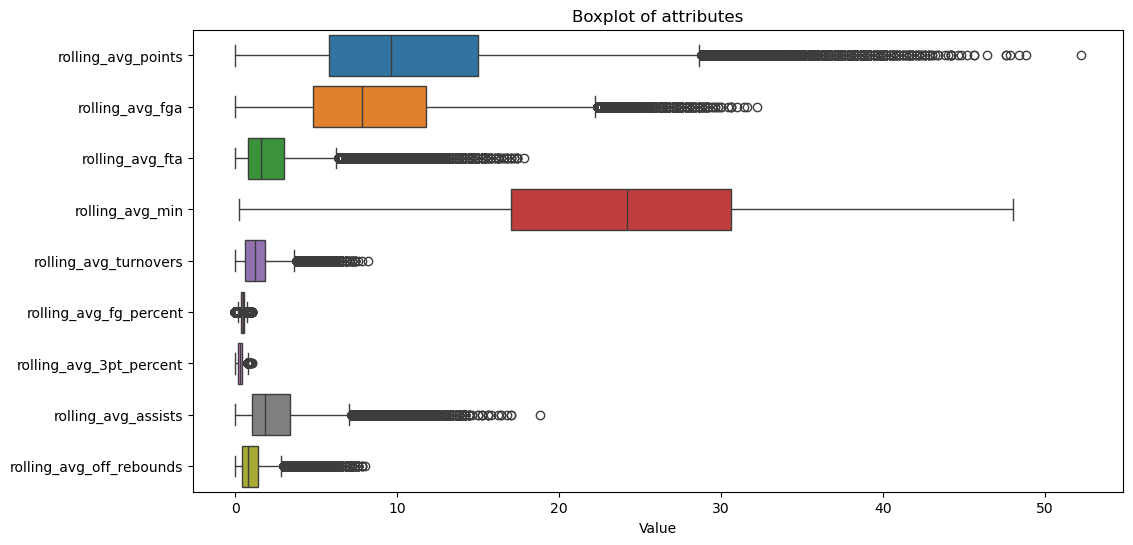

In [18]:
# Box plot to check outliers
columns_to_check = [
    'rolling_avg_points',
    'rolling_avg_fga',
    'rolling_avg_fta',
    'rolling_avg_min',
    'rolling_avg_turnovers',
    'rolling_avg_fg_percent',
    'rolling_avg_3pt_percent',
    'rolling_avg_assists',
    "rolling_avg_off_rebounds"
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=last_10_years_data[columns_to_check], orient='h')
plt.title('Boxplot of attributes')
plt.xlabel('Value')
plt.show()

<b>Noticed </b>that the only metric with low end outliers was rolling_avg_fg_percent. Hard to see

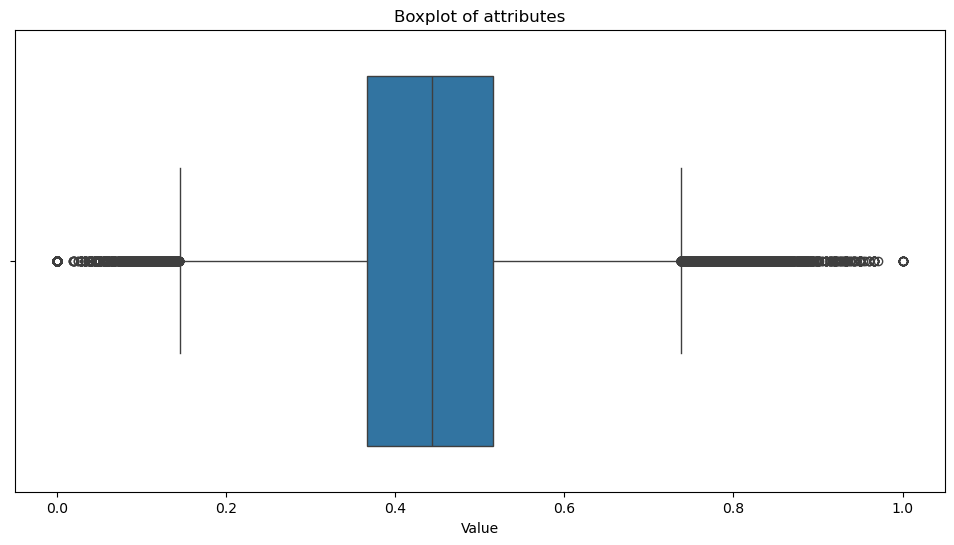

In [19]:
# To get a better picture of the box plot with low end outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=last_10_years_data['rolling_avg_fg_percent'], orient='h')
plt.title('Boxplot of attributes')
plt.xlabel('Value')
plt.show()

In [20]:
# Exploring what records were displaying as outliers
last_10_years_data[last_10_years_data['rolling_avg_fg_percent'] <= .1]

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threshold_25,rolling_avg_points,rolling_avg_fg_percent,rolling_avg_min,rolling_avg_fga,rolling_avg_turnovers,rolling_avg_fta,rolling_avg_3pt_percent,rolling_avg_assists,rolling_avg_off_rebounds
376346,Vince,Carter,1713.0,21500534,2016-01-06 21:30:00,Memphis,Grizzlies,Oklahoma City,Thunder,Regular Season,...,0,0.6,0.0666,9.200,2.8,0.2,0.4,0.0000,1.0,0.0
313387,Vince,Carter,1713.0,21700132,2017-11-04 19:00:00,Sacramento,Kings,Detroit,Pistons,Regular Season,...,0,1.0,0.0666,8.200,3.0,0.6,0.4,0.1000,0.4,0.0
381213,Paul,Pierce,1718.0,21500344,2015-12-12 17:00:00,Los Angeles,Clippers,Brooklyn,Nets,Regular Season,...,0,1.2,0.0666,7.600,2.2,0.8,0.8,0.0666,0.2,0.0
312907,Jason,Terry,1891.0,21700149,2017-11-07 19:00:00,Milwaukee,Bucks,Cleveland,Cavaliers,Regular Season,...,0,2.0,0.0858,9.400,2.6,0.4,0.4,0.1000,1.0,0.4
298638,Jason,Terry,1891.0,21700719,2018-01-26 20:00:00,Milwaukee,Bucks,Brooklyn,Nets,Regular Season,...,0,0.0,0.0000,6.800,1.4,0.4,0.0,0.0000,0.2,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14614,Brooks,Barnhizer,1642964.0,22500641,2026-01-23 20:00:00,Oklahoma City,Thunder,Indiana,Pacers,Regular Season,...,0,0.0,0.0000,8.206,0.8,0.0,0.0,0.0000,0.4,0.2
7140,Brooks,Barnhizer,1642964.0,22500920,2026-03-07 20:30:00,Oklahoma City,Thunder,Golden State,Warriors,Regular Season,...,0,0.0,0.0000,6.448,1.0,0.2,0.0,0.0000,0.4,0.0
157,Brooks,Barnhizer,1642964.0,22501182,2026-04-10 21:00:00,Oklahoma City,Thunder,Denver,Nuggets,Regular Season,...,0,0.4,0.1000,5.858,0.6,0.0,0.0,0.0000,0.2,1.0
20346,Taelon,Peter,1643007.0,22500426,2025-12-26 19:00:00,Indiana,Pacers,Boston,Celtics,Regular Season,...,0,0.2,0.0000,2.044,0.6,0.2,0.4,0.0000,0.0,0.0


Showed how players can also have low light games. Normal to keep

In [21]:
# Shows the propprtion of classes - the higher the threshold the greater the imbalance is 
print(round(last_10_years_data['threshold_10'].sum()/last_10_years_data.shape[0],2))
print(round(last_10_years_data['threshold_15'].sum()/last_10_years_data.shape[0],2))
print(round(last_10_years_data['threshold_20'].sum()/last_10_years_data.shape[0],2))
print(round(last_10_years_data['threshold_25'].sum()/last_10_years_data.shape[0],2))

0.46
0.27
0.14
0.07


<b>What we found </b> Is that for the most part, there will be a class imbalance depending on the point threshold selected

<h2>Correlation Analysis</h2>

In [22]:
# Correlation metric for scoring flag!
corr_threshold_10 = last_10_years_data.corr(numeric_only=True)['threshold_10'].sort_values(ascending=False)
corr_threshold_15 = last_10_years_data.corr(numeric_only=True)['threshold_15'].sort_values(ascending=False)
corr_threshold_20 = last_10_years_data.corr(numeric_only=True)['threshold_20'].sort_values(ascending=False)
corr_threshold_25 = last_10_years_data.corr(numeric_only=True)['threshold_25'].sort_values(ascending=False)

# Concatting the corr analysis together
corr_df = pd.concat(
    [corr_threshold_10, corr_threshold_15, corr_threshold_20, corr_threshold_25],
    axis = 1
)

# Adding a mean column
corr_df['mean'] = corr_df.mean(axis = 1)

# Only looking at important cols
corr_df = corr_df.loc[columns_to_check]

# Sort by mean
corr_df.sort_values(by="mean", ascending = False)

,threshold_10,threshold_15,threshold_20,threshold_25,mean
rolling_avg_points,0.539096,0.566514,0.527539,0.443602,0.519188
rolling_avg_fga,0.548549,0.569809,0.523447,0.430467,0.518068
rolling_avg_fta,0.427116,0.471850,0.461111,0.408739,0.442204
rolling_avg_min,0.488255,0.458948,0.385280,0.294942,0.406856
rolling_avg_turnovers,0.407184,0.433092,0.407911,0.345782,0.398492
rolling_avg_assists,0.357767,0.382184,0.363601,0.310223,0.353444
rolling_avg_3pt_percent,0.179823,0.166093,0.139548,0.104608,0.147518
rolling_avg_fg_percent,0.137809,0.109587,0.082614,0.063265,0.098319
rolling_avg_off_rebounds,0.112485,0.084692,0.053224,0.033654,0.071014


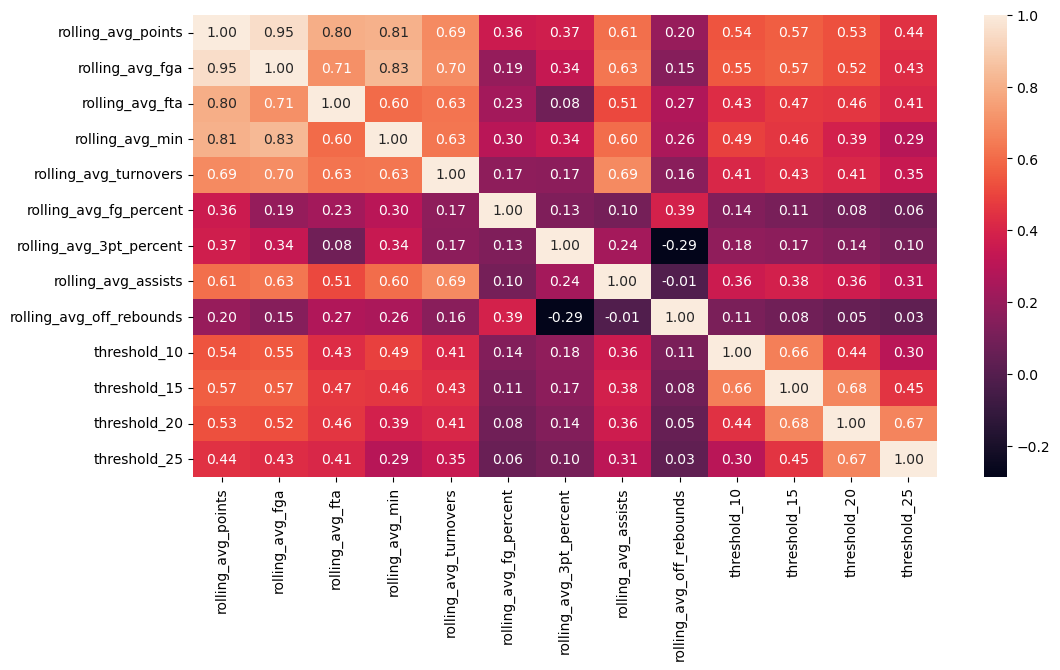

In [23]:
#Deciding on which features to display is important as we are trying to show all audiences what the most important features are and why
corr_features = list(corr_df.index.values) + ["threshold_10"] + ["threshold_15"] + ["threshold_20"] + ["threshold_25"]

plt.figure(figsize=(12,6))
sns.heatmap(last_10_years_data[corr_features].corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

In [24]:
# Creating a list of cols to keep to train our model on
# We only keep numeric metrics considered relevent (needs to have a cor score of over 20%)
cols_to_keep = list(corr_df[corr_df['mean'] >= 0.2].sort_values(by="mean", ascending=False).index.values) + ["opponentteamName"] + ["points"]
cols_to_keep 

['rolling_avg_points',
 'rolling_avg_fga',
 'rolling_avg_fta',
 'rolling_avg_min',
 'rolling_avg_turnovers',
 'rolling_avg_assists',
 'opponentteamName',
 'points']

In [25]:
nba_model_data = last_10_years_data[cols_to_keep]
nba_model_data

,rolling_avg_points,rolling_avg_fga,rolling_avg_fta,rolling_avg_min,rolling_avg_turnovers,rolling_avg_assists,opponentteamName,points
389651,7.6,6.2,0.8,19.200,0.2,1.6,Lakers,4.0
389341,7.4,5.6,0.4,18.000,0.2,1.6,Nuggets,4.0
388823,7.0,5.4,0.8,19.400,0.2,1.2,Trail Blazers,0.0
388280,4.6,4.0,1.2,18.400,0.2,1.4,Heat,0.0
387892,2.4,3.0,0.8,16.400,0.2,1.2,Bulls,2.0
...,...,...,...,...,...,...,...,...
2719,7.2,5.4,1.6,19.874,1.8,3.4,Kings,4.0
2372,7.2,5.0,1.2,16.664,1.6,2.6,Hornets,11.0
1718,8.0,5.6,0.8,18.832,1.6,2.0,Hawks,11.0
1422,7.8,5.4,0.8,18.042,1.2,2.2,Wizards,9.0


In [26]:
# One hot encoded team name 
nba_model_data = pd.get_dummies(nba_model_data, columns=["opponentteamName"], drop_first=True).astype(float)
nba_model_data

,rolling_avg_points,rolling_avg_fga,rolling_avg_fta,rolling_avg_min,rolling_avg_turnovers,rolling_avg_assists,points,opponentteamName_Bucks,opponentteamName_Bulls,opponentteamName_Cavaliers,...,opponentteamName_Pistons,opponentteamName_Raptors,opponentteamName_Rockets,opponentteamName_Spurs,opponentteamName_Suns,opponentteamName_Thunder,opponentteamName_Timberwolves,opponentteamName_Trail Blazers,opponentteamName_Warriors,opponentteamName_Wizards
389651,7.6,6.2,0.8,19.200,0.2,1.6,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
389341,7.4,5.6,0.4,18.000,0.2,1.6,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
388823,7.0,5.4,0.8,19.400,0.2,1.2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
388280,4.6,4.0,1.2,18.400,0.2,1.4,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
387892,2.4,3.0,0.8,16.400,0.2,1.2,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2719,7.2,5.4,1.6,19.874,1.8,3.4,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2372,7.2,5.0,1.2,16.664,1.6,2.6,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1718,8.0,5.6,0.8,18.832,1.6,2.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1422,7.8,5.4,0.8,18.042,1.2,2.2,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [27]:
# Capturing user-input for Point Threshold - turn on later or add in code when running 
while True:
    try:
        point_threshold = float(input("Enter point threshold: "))
        break
    except ValueError:
        print("Please enter a valid number.")

Enter point threshold:  25


In [28]:
# Creating a calculated column of our target variable
nba_model_data["threshold"] = np.where(nba_model_data["points"] > point_threshold, 1, 0)

In [29]:
# Splitting data into predictors and label
X = nba_model_data.drop(columns = ["points", "threshold"]) #Points is our predictor
y = nba_model_data[["threshold"]]

In [30]:
# Creating the training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 502,
    stratify = y 
)

In [31]:
# Initialize scaler
scaler = StandardScaler()

# To keep things dynamic in case we decide to change metrics to show
cols_to_keep = list(corr_df[corr_df['mean'] >= 0.2].sort_values(by="mean", ascending=False).index.values)

# Standardizing numeric cols for training dataset
X_train[cols_to_keep] = scaler.fit_transform(X_train[cols_to_keep])
X_test[cols_to_keep] = scaler.transform(X_test[cols_to_keep])

In [32]:
# Training the Logistic Regression Model
clf = LogisticRegression(random_state=502)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",502
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [33]:
X_train_graph_val = "rolling_avg_points" #Simply changing this variable we can look at different predictors for our logistic graph
X_range = np.linspace(X_train[X_train_graph_val].min(), X_train[X_train_graph_val].max(), 200) #Generate 200 data points to show on Logistic Regression graph

#Made a dataframe dictionary comprehension to loop through standardized values and obtain the mean of the players stats. This gets the idea of what an average player statistically performs
X_train_plot = pd.DataFrame({
    col: [X_train[col].mean()] * len(X_range)
    for col in X_train.columns
})
X_train_plot[X_train_graph_val] = X_range

y_prob = clf.predict_proba(X_train_plot)[:,1] #predicting the likelihood of exceeding threshold or probability of "1"

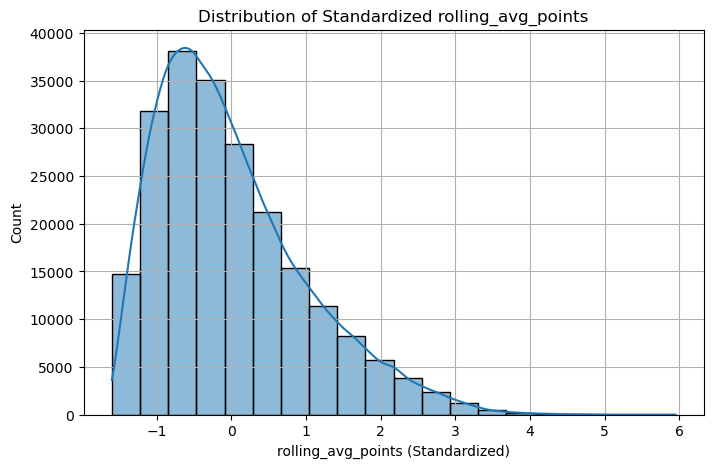

In [34]:
#Before looking at the logistic regression let's show the distribution of players that are likely to exceed threshold (generally) 
plt.figure(figsize=(8,5))
sns.histplot(X_train[X_train_graph_val], kde=True, bins=20)
plt.xlabel(f"{X_train_graph_val} (Standardized)")
plt.ylabel("Count")
plt.title(f"Distribution of Standardized {X_train_graph_val}")
plt.grid(True)
plt.show()

The distribution of standardized rolling_avg_points shows that most players cluster around their average scoring performance, with less of the players going above or below in their average scoring output.  The distribution is right skewed, showing there are more players who exceed their typical scoring average than players who fall below it. This makes rolling_avg_points a meaningful predictor for our logistic regression model because players who have been scoring above their recent average are more likely to exceed the scoring threshold in the next game.

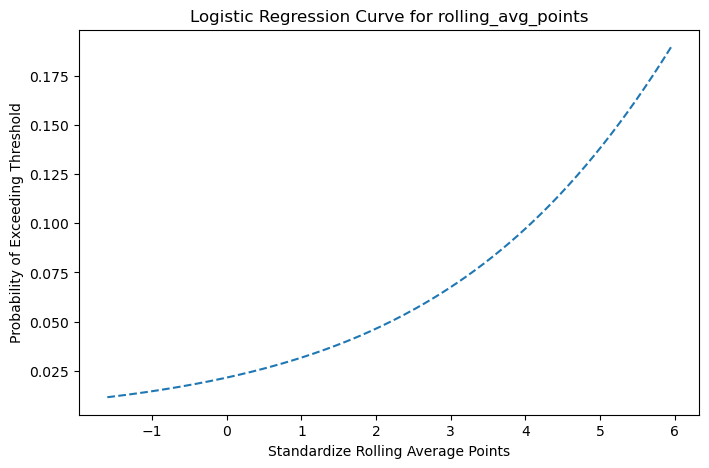

In [35]:
#Logistic Regression shows how likely a player is to exceed threshold based on how much they have scored recently
plt.figure(figsize=(8,5))
plt.plot(X_range, y_prob, '--')
plt.xlabel("Standardize Rolling Average Points")
plt.ylabel("Probability of Exceeding Threshold")
plt.title(f"Logistic Regression Curve for {X_train_graph_val}")
plt.show()

The logistic regression plot illustrates how the model’s predicted probability of exceeding the scoring threshold changes as a player’s recent scoring performance varies. Logistic regression outputs probabilities between 0 and 1, so the y‑axis represents the likelihood of a player going over the threshold. We selected rolling_avg_points as the predictor to visualize because it showed the strongest relationship with the target variable because players who have been scoring more in recent games are more likely to exceed a future scoring threshold. The x‑axis represents the standardized values of rolling_avg_points. Standardization means the feature has been transformed so that so a 0 on the graph represents an average recent scoring performance, positive digits represent above average scoring, and negative values show below average scoring. When rolling average increases, the predicted probability of exceeding the threshold increases, showing that NBA player can get on hot scoring streaks. This demonstrates that recent scoring is a meaningful predictor of whether a player will surpass the expected point total. When choosing a higher thresholds, it will produce lower probabilities, since scoring large point totals in the NBA is difficult, even for the best players.

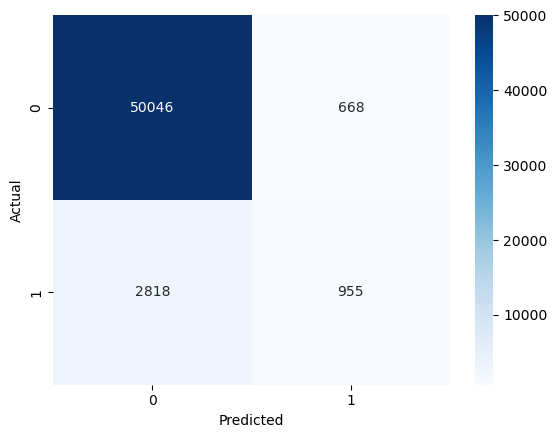

In [36]:
#Confusion matrix showing the accuracy of the model
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
#this function was made so that we can evaluate multiple models
def evaluate_model(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    TN = cm[0][0] #how many times the threshold predicted 0 and was 0 
    FP = cm[0][1] #how many times the threshold predicted 1 and was 0
    FN = cm[1][0] #how many times the threshold predicted 0 and was 1 
    TP = cm[1][1] #how many times the threshold predicted 1 and was 1 

    #total actually positive 
    TAP = TP + FN

    #total actually negative
    TAN = FP + TN

    #total predictions positive
    TPP = FP + TP

    #total predictions negative
    TPN = FN + TN

    accuracy = (TN + TP) / (TN + FP + FN + TP)
    error_rate = 1 - accuracy
    sensitivity = TP / TAP if TAP else 0
    specificity = TN / TAN if TAN else 0
    precision = TP / TPP if TPP else 0
    recall = sensitivity

    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    f2 = 5 * (precision * recall) / ((4 * precision) + recall) if ((4 * precision) + recall) else 0
    f05 = 1.25 * (precision * recall) / ((0.25 * precision) + recall) if ((0.25 * precision) + recall) else 0

    data = {
        "Evaluation Measure": [
            "Accuracy",
            "Error rate",
            "Sensitivity (Recall)",
            "Specificity",
            "Precision",
            "F1 Score",
            "F2 Score",
            "F0.5 Score"
        ],
        "Value": [
            accuracy,
            error_rate,
            sensitivity,
            specificity,
            precision,
            f1,
            f2,
            f05
        ]
    }

    return pd.DataFrame(data).round(2)

In [38]:
log_reg_table = evaluate_model(y_test, y_pred)
log_reg_table

,Evaluation Measure,Value
0,Accuracy,0.94
1,Error rate,0.06
2,Sensitivity (Recall),0.25
3,Specificity,0.99
4,Precision,0.59
5,F1 Score,0.35
6,F2 Score,0.29
7,F0.5 Score,0.47


In [39]:
# Random forest
forest = RandomForestClassifier(n_estimators=100, random_state=502, class_weight = "balanced")
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)

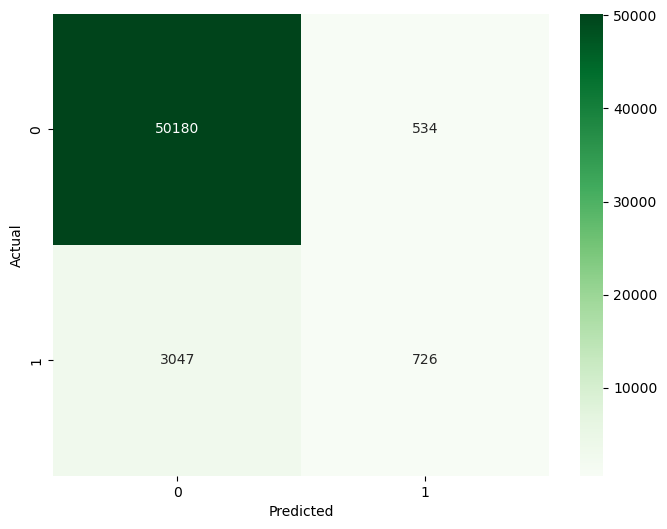

In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
rand_forest_table = evaluate_model(y_test, y_pred)
rand_forest_table

,Evaluation Measure,Value
0,Accuracy,0.93
1,Error rate,0.07
2,Sensitivity (Recall),0.19
3,Specificity,0.99
4,Precision,0.58
5,F1 Score,0.29
6,F2 Score,0.22
7,F0.5 Score,0.41


In [42]:
#Comparing Random Forest vs Logistic Regression
tables = pd.concat(
    [
        log_reg_table.set_index("Evaluation Measure"),
        rand_forest_table.set_index("Evaluation Measure")
    ],
    axis=1
)

tables.columns = ["Logistic Regression", "Random Forest"]
tables

,Logistic Regression,Random Forest
Evaluation Measure,,
Accuracy,0.94,0.93
Error rate,0.06,0.07
Sensitivity (Recall),0.25,0.19
Specificity,0.99,0.99
Precision,0.59,0.58
F1 Score,0.35,0.29
F2 Score,0.29,0.22
F0.5 Score,0.47,0.41


In [43]:
team_to_select_df = pd.DataFrame(
    sorted(last_10_years_data['playerteamName'].unique()),
    columns = ["team"]
)

team_to_select_df

,team
0,76ers
1,Bucks
2,Bulls
3,Cavaliers
4,Celtics
5,Clippers
6,Grizzlies
7,Hawks
8,Heat
9,Hornets


In [44]:
# Capturing user-input for Point Threshold - turn on later or add in code when running 
while True:
    try:
        team_selected = int(input("Please enter the team index your player has played for in the last 10 years: "))
        
        if 0 <= team_selected <= 29:
            break
        else:
            print("Number must be between 0 and 29.")
    
    except ValueError:
        print("Please enter a valid integer.")

print("You've selected the " + team_to_select_df.iloc[team_selected]["team"])

Please enter the team index your player has played for in the last 10 years:  13


You've selected the Lakers


In [45]:
pd.set_option('display.max_rows', None)

filtered_team_stats = last_10_years_data[last_10_years_data['playerteamName'] == team_to_select_df.iloc[team_selected]["team"]]
filtered_team_stats["fullName"] = filtered_team_stats["firstName"] + " " + filtered_team_stats["lastName"]
player_to_select_df = filtered_team_stats[["fullName", "personId"]].drop_duplicates().sort_values("fullName").reset_index(drop=True)
player_to_select_df[["fullName"]]

,fullName
0,Adou Thiero
1,Alex Caruso
2,Alex Len
3,Alfonzo McKinnie
4,Andre Drummond
5,Andrew Bogut
6,Anthony Brown
7,Anthony Davis
8,Armel Traore
9,Austin Reaves


In [46]:
# Capturing user-input for Point Threshold - turn on later or add in code when running 
while True:
    try:
        player_selected = int(input("Please enter the index of the player you want to select: "))
        
        if 0 <= player_selected <= player_to_select_df.shape[0] - 1:
            break
        else:
            print("Number must be within range")
    
    except ValueError:
        print("Please enter a valid integer.")

print("You've selected " + player_to_select_df.iloc[player_selected]["fullName"])
player_selected_id = player_to_select_df.iloc[player_selected]["personId"]

Please enter the index of the player you want to select:  77


You've selected Luka Doncic


In [47]:
# Capturing user-input for Point Threshold - turn on later or add in code when running 
while True:
    try:
        opponent_team_selected = int(input("Please enter the team index your player is playing against: "))
        
        if 0 <= opponent_team_selected <= 29 and team_selected != opponent_team_selected:
            break
        else:
            print("Number must be between 0 and 29 and can't be the same team")
    
    except ValueError:
        print("Please enter a valid integer.")

print("You've selected the " + team_to_select_df.iloc[opponent_team_selected]["team"])

Please enter the team index your player is playing against:  3


You've selected the Cavaliers


In [48]:
# Returns Players Latest stats to push to the model
pd.reset_option('display.max_rows')

df = last_10_years_data.copy()
df[cols_to_keep] = scaler.transform(df[cols_to_keep]) # standardizing the numeric values
df

# Filtering to selected player and their latest game stats
selected_player_df = df[df['personId'] == player_selected_id].sort_values('gameDateTimeEst', ascending = False).iloc[[0]][cols_to_keep]
selected_player_df

irrelevant_teams = X_train.drop(columns = cols_to_keep + [("opponentteamName_" + team_to_select_df.iloc[opponent_team_selected]["team"])]).columns

for team in irrelevant_teams:
    selected_player_df[team] = 0

selected_player_df[("opponentteamName_" + team_to_select_df.iloc[opponent_team_selected]["team"])] = 1

selected_player_df = selected_player_df[X_train.columns]



In [49]:
player_name = player_to_select_df.iloc[player_selected]["fullName"]

logistic_regression_prediction = clf.predict(selected_player_df)[0] # pull class prediction
logistic_regression_label = "over" if logistic_regression_prediction == 1 else "under" # calc over or under
logistic_regression_prob = clf.predict_proba(selected_player_df)[0][logistic_regression_prediction] # pulls probability or confidence level

random_forest_prediction = forest.predict(selected_player_df)[0] # pull class prediction
random_forest_label = "over" if random_forest_prediction == 1 else "under" # calc over or under
random_forest_prob = forest.predict_proba(selected_player_df)[0][random_forest_prediction] # pulls probability or confidence level 

print(
    f"Random Forest predicts {player_name} will score {random_forest_label} "
    f"{point_threshold} with a probability of {random_forest_prob * 100:.2f}%."
)

print(
    f"Logistic Regression predicts {player_name} will score {logistic_regression_label} "
    f"{point_threshold} with a probability of {logistic_regression_prob * 100:.2f}%."
)

Random Forest predicts Luka Doncic will score over 25.0 with a probability of 54.00%.
Logistic Regression predicts Luka Doncic will score over 25.0 with a probability of 91.27%.


In [50]:
# Obtain all player information using a boolean mask. The mask is checking if the player_id matches.
# Essentially get all the games they have ever played, sort by date(earliest date to latest date) and store them in a variable called player history. 
player_history = last_10_years_data[last_10_years_data['personId'] == player_selected_id].sort_values('gameDateTimeEst')

In [51]:
#Display a player's last 5 games scoring. This gives an idea of what point thresholds would be good for each player. 
player_history[['firstName', 'lastName', 'points', 'rolling_avg_points']].tail(5)

,firstName,lastName,points,rolling_avg_points
3924,Luka,Doncic,32.0,39.8
3616,Luka,Doncic,43.0,40.2
3009,Luka,Doncic,41.0,41.6
2252,Luka,Doncic,42.0,41.8
1892,Luka,Doncic,12.0,38.2


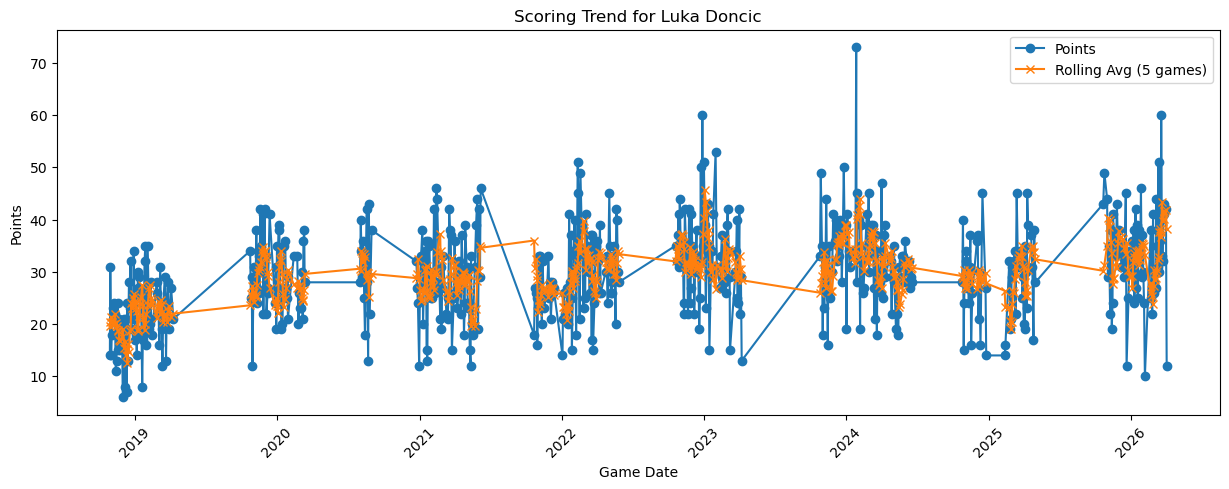

In [52]:
#Graphing the players rolling_avg_points and points scored. This graph shows scoring trends and shows when a player got a hot scoring run or a cold scoring run
plt.figure(figsize=(15, 5))
plt.plot(player_history['gameDateTimeEst'], player_history['points'], label='Points', marker='o')
plt.plot(player_history['gameDateTimeEst'], player_history['rolling_avg_points'], label='Rolling Avg (5 games)', marker='x')
plt.xticks(rotation=45)
plt.title(f"Scoring Trend for {player_to_select_df.iloc[player_selected]['fullName']}")
plt.xlabel("Game Date")
plt.ylabel("Points")
plt.legend()
plt.show()